In [8]:
# imports
import importlib
import download_data
importlib.reload(download_data)
from download_data import get_merged_data
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap
import holidays
import requests
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from optuna.integration import XGBoostPruningCallback
from xgboost import XGBRegressor
import matplotlib.gridspec as gridspec


In [9]:
# complete feature engineering
df = pd.DataFrame()
df = get_merged_data()

# create new features based on the kind of day like workday
at_holidays = holidays.Austria()

df["is_weekend"] = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"] = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["dow"] = df["day_of_week"]  # alias for compatibility
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1
df['is_workday'] = (~df['is_weekend'] & ~df['is_holiday']).astype(int)
df["hour"] = df["DateTime"].dt.hour
df["quarter_hr"] = df["DateTime"].dt.minute // 15
df["month"] = df["DateTime"].dt.month

# encode cyclical time (24h)
seconds_in_day = 24 * 60 * 60
time_in_seconds = (
    df["DateTime"].dt.hour * 3600
    + df["DateTime"].dt.minute * 60
    + df["DateTime"].dt.second
)
df["time_sin"] = np.sin(2 * np.pi * time_in_seconds / seconds_in_day)
df["time_cos"] = np.cos(2 * np.pi * time_in_seconds / seconds_in_day)

# encode cyclical day of the year
DOY = df['DateTime'].dt.dayofyear
angle = 2 * np.pi * DOY / 365
df['doy_sin'] = np.sin(angle)
df['doy_cos'] = np.cos(angle)

# delete old dayahead columns
dayahead_cols = df.filter(like="DayAhead").columns
df = df.drop(columns=dayahead_cols)

# delete rows before 1.10.2018 (limits modell size and also no weather API for older data)
cutoff = pd.Timestamp("2018-10-01")
df = df[df["DateTime"] >= cutoff]

# delete all rows with NaNs and cut off incomplete tail
full_rows = ~df.isna().any(axis=1)
last_full_idx = full_rows[full_rows].index[-1]
df = df.loc[:last_full_idx]

# add lag features
lags = [1, 2, 3, 4, 8, 12, 24, 48, 96]
for lag in lags:
    df[f"load_lag_{lag}"] = df["Load_Actual"].shift(lag)

# add differenced load features
df["load_diff_1"] = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"] = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"] = df["load_lag_1"] - df["load_lag_96"]
df["diff_15m"] = df["Load_Actual"].diff(1)

# rolling statistics
df["load_mean_1h"] = df["Load_Actual"].rolling(4).mean()
df["load_std_1h"] = df["Load_Actual"].rolling(4).std()
df["load_ramp_1h"] = df["Load_Actual"].rolling(4).max() - df["Load_Actual"].rolling(4).min()
df["load_mean_3h"] = df["Load_Actual"].rolling(12).mean()
df["load_mean_12h"] = df["Load_Actual"].rolling(48).mean()
df["load_mean_24h"] = df["Load_Actual"].rolling(96).mean()

# multi-horizon targets
HORIZON = 96
for k in range(1, HORIZON + 1):
    df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)

# delete NaNs after feature engineering
df = df.dropna().reset_index(drop=True)

# get start and end date for weather data
start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# example: coordinates for Vienna
latitude = 48.2082
longitude = 16.3738

# query weather data via API
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}
response = requests.get(url, params=params)
data = response.json()

# weather dataframe
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)

# format weather time column
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])

# sort datetime columns
df = df.sort_values("DateTime")
weather = weather.sort_values("time")

# merge on datetime (left join: df ← weather)
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="backward")

# drop weather time column
df = df.drop(columns=["time"])

# parameter for the curvature strength
p = 1.2  # 1 = linear, >1 = stronger increase at extreme values

# heating demand: stronger increase below 15 °C
df["heating_demand"] = df["temperature_2m"].apply(lambda t: (15 - t) ** p if t < 15 else 0)

# cooling demand: stronger increase above 22 °C
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: (t - 22) ** p if t > 22 else 0)


C:\Users\Julia\AppData\Local\Temp\ipykernel_2120\680840306.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)
C:\Users\Julia\AppData\Local\Temp\ipykernel_2120\680840306.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{k}"] = df["Load_Actual"].shift(-k)
C:\Users\Julia\AppData\Local\Temp\ipykernel_2120\680840306.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

In [17]:
# clean up / final dataset
df = df.dropna().reset_index(drop=True)

# target & feature columns
target_cols  = [f"target_t+{k}" for k in range(1, HORIZON + 1)]
exclude      = {"DateTime", "Load_Actual", *target_cols}
feature_cols = [c for c in df.columns if c not in exclude]

X, y = df[feature_cols], df[target_cols]

# train / test split (time-order)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)


import optuna, numpy as np, joblib, warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from optuna.integration import XGBoostPruningCallback

FOLDS = 3         # 3-fold CV  → schneller
GPU   = True      # CUDA verfügbar

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int  ("n_estimators", 200, 600),  # gedeckelt
        "max_depth":        trial.suggest_int  ("max_depth",       3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample",     0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight",0.1, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma",           0, 5),
        "objective":        "reg:squarederror",
        "eval_metric":      "rmse",
        "random_state":     42,
        "n_jobs":           -1,
        "tree_method":      "hist",
        "device":           "cuda" if GPU else "cpu",
    }

    cv = TimeSeriesSplit(n_splits=FOLDS)
    rmses = []

    for tr_idx, va_idx in cv.split(X_tr):
        Xt, Xv = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        yt, yv = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]

        preds = []
        for h in range(yt.shape[1]):           # 96 Horizonte
            reg = XGBRegressor(
                **params,
                callbacks=[
                    EarlyStopping(rounds=30),
                    XGBoostPruningCallback(trial, "validation_0-rmse"),
                ],
            )
            reg.fit(Xt, yt.iloc[:, h],
                    eval_set=[(Xv, yv.iloc[:, h])],
                    verbose=False)
            preds.append(reg.predict(Xv))

        y_pred = np.column_stack(preds)
        rmses.append(np.sqrt(mean_squared_error(yv, y_pred)))

    return np.mean(rmses)

warnings.filterwarnings("ignore", message="The reported value is ignored.*")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner =optuna.pruners.MedianPruner(n_warmup_steps=3),   # aggressiver
)

study.optimize(objective,
               n_trials=20,            # nur 20 Trials
               show_progress_bar=True) # Live-Fortschritt

best_params = study.best_params
best_params.update({
    "objective":   "reg:squarederror",
    "eval_metric": "rmse",
    "n_jobs":      -1,
    "tree_method": "hist",
    "device":      "cuda" if GPU else "cpu",
})

# --------------------------------------------------  FINAL MODEL  ----------------------------------------------
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

base  = XGBRegressor(**best_params)
model = MultiOutputRegressor(base)
model.fit(X_tr, y_tr)

joblib.dump(model, "best_xgb_multi.pkl")  # persist model

y_pred = pd.DataFrame(model.predict(X_te),
                      columns=target_cols, index=y_te.index)

rmse_h = np.sqrt(((y_te - y_pred) ** 2).mean())
mape_h = (np.abs((y_te - y_pred) / y_te).mean()) * 100
mae_h  = mean_absolute_error(y_te, y_pred, multioutput="raw_values")

print(f"Mean MAPE : {mape_h.mean():.2f}%")
print(f"Mean RMSE : {rmse_h.mean():.2f} kW")
print(f"Mean MAE  : {mae_h.mean():.2f} kW")
print("Model saved to best_xgb_multi.pkl")


[I 2025-06-30 21:19:02,327] A new study created in memory with name: no-name-bee444a7-a9a2-4af9-b60d-e0a0a875df60


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-06-30 21:38:38,887] Trial 0 finished with value: 330.63497984756947 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 0.2051110418843398, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 330.63497984756947.
[I 2025-06-30 21:52:37,345] Trial 1 finished with value: 333.33556229186865 and parameters: {'n_estimators': 547, 'max_depth': 7, 'learning_rate': 0.05675206026988748, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 4.622589001020832, 'gamma': 1.0616955533913808}. Best is trial 0 with value: 330.63497984756947.
[I 2025-06-30 22:01:13,395] Trial 2 finished with value: 560.7525581260189 and parameters: {'n_estimators': 272, 'max_depth': 4, 'learning_rate': 0.005670807781371429, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'min_child_weight': 0.38234752246751863, '

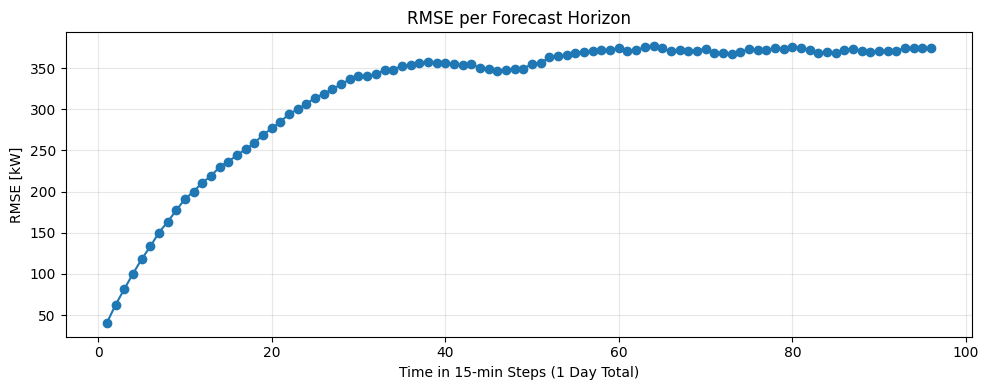

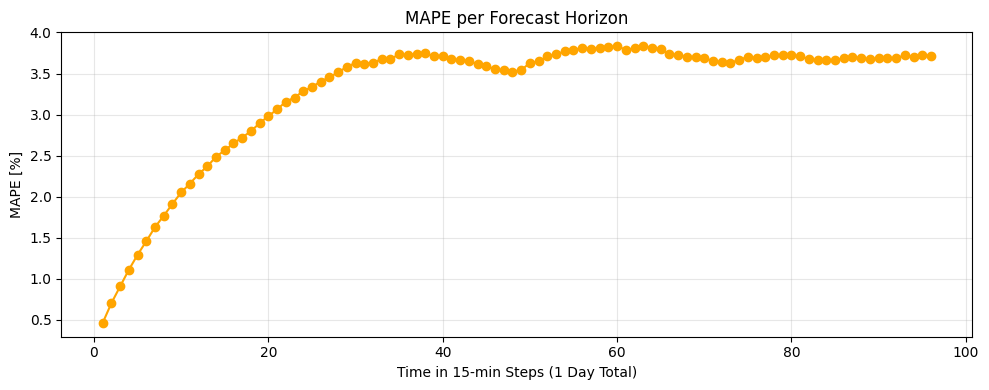

In [24]:
# MAPE & RMSE per forecast horizon
rmse_vals = rmse_h.values
mape_vals = mape_h.values
horizons  = np.arange(1, len(rmse_vals) + 1)

plt.figure(figsize=(10, 4))
plt.plot(horizons, rmse_vals, marker="o")
plt.ylabel("RMSE [kW]")
plt.xlabel("Time in 15-min Steps (1 Day Total)")
plt.title("RMSE per Forecast Horizon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(horizons, mape_vals, marker="o", color="orange")
plt.ylabel("MAPE [%]")
plt.xlabel("Time in 15-min Steps (1 Day Total)")
plt.title("MAPE per Forecast Horizon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<>:58: SyntaxWarning: 'list' object is not callable; perhaps you missed a comma?
<>:58: SyntaxWarning: 'list' object is not callable; perhaps you missed a comma?
C:\Users\Julia\AppData\Local\Temp\ipykernel_2120\2810506892.py:58: SyntaxWarning: 'list' object is not callable; perhaps you missed a comma?
  handles = [ax1.containers]()


TypeError: 'list' object is not callable

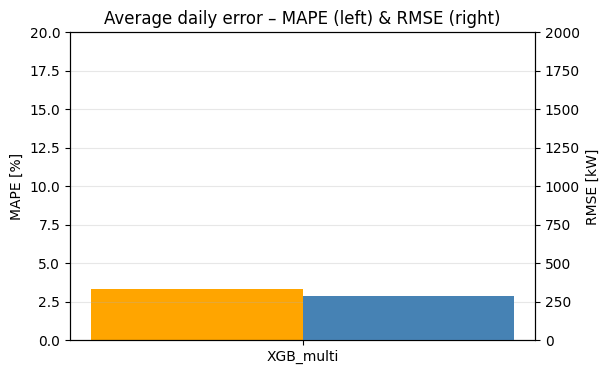

In [82]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- load metrics -------------------------------------------------------------
file = Path("forecast_metrics.json")
with file.open() as f:
    data = json.load(f)

# always work with a list of dicts
if isinstance(data, dict):
    data = [data]

df = pd.DataFrame(data)

# rename columns if the JSON used different keys
renamer = {"rmse": "avg_rmse", "mape": "avg_mape"}
df = df.rename(columns=renamer)

# drop rows without both metrics
df = df.dropna(subset=["avg_rmse", "avg_mape"])

if df.empty:
    raise ValueError("No valid 'avg_rmse' / 'avg_mape' found in JSON.")

df["model"] = df["model"].astype(str)
df["avg_rmse"] = df["avg_rmse"].astype(float)
df["avg_mape"] = df["avg_mape"].astype(float)

# --- plot ---------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

width = 0.25
x_pos = range(len(df))

# MAPE bars (left axis)
ax1.bar([p - width / 2 for p in x_pos],
        df["avg_mape"], width=width, color="orange", label="MAPE [%]")

# RMSE bars (right axis)
ax2.bar([p + width / 2 for p in x_pos],
        df["avg_rmse"], width=width, color="steelblue", label="RMSE [kW]")

# labels & axes
ax1.set_ylabel("MAPE [%]")
ax2.set_ylabel("RMSE [kW]")
ax1.set_ylim(0, 20)
ax2.set_ylim(0, 2000)

ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(df["model"])
ax1.set_title("Average daily error – MAPE (left) & RMSE (right)")
ax1.grid(axis="y", alpha=0.3)

# unified legend
handles = [ax1.containers]()



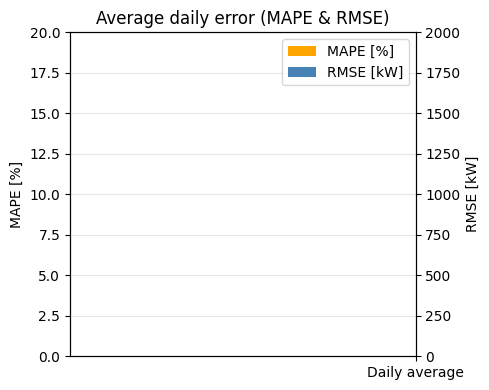

In [81]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- load JSON -------------------------------------------------------------
file = Path("forecast_metrics.json")
with file.open() as f:
    data = json.load(f)

if isinstance(data, dict):
    data = [data]

df = pd.DataFrame(data)

# pick the first (or filter by name)
avg_rmse = float(df.iloc[0]["avg_rmse"])
avg_mape = float(df.iloc[0]["avg_mape"])

# --- plot ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(5, 4))
ax2 = ax1.twinx()

width = 0.2
ax1.bar(0,        avg_mape, width=width, color="orange",    label="MAPE [%]")
ax2.bar(0 + 0.25, avg_rmse, width=width, color="steelblue", label="RMSE [kW]")

ax1.set_ylabel("MAPE [%]")
ax2.set_ylabel("RMSE [kW]")
ax1.set_ylim(0, 20)
ax2.set_ylim(0, 2000)

ax1.set_xticks([0.125])
ax1.set_xticklabels(["Daily average"])
ax1.set_title("Average daily error (MAPE & RMSE)")
ax1.grid(axis="y", alpha=0.3)

handles = [ax1.containers[0], ax2.containers[0]]
labels  = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


In [83]:
import json
from pathlib import Path
import pprint

# adjust the path if the file is elsewhere
json_path = Path("forecast_metrics.json")

with json_path.open() as f:
    data = json.load(f)

print("Raw content of forecast_metrics.json:")
pprint.pprint(data, width=120)


Raw content of forecast_metrics.json:
[{'MAPE_total': 15.7694152482, 'RMSE_total': 1425.3628592623, 'avg_mape': None, 'avg_rmse': None, 'model': None},
 {'MAPE_total': None, 'RMSE_total': None, 'avg_mape': 3.3016890192, 'avg_rmse': 287.3258247827, 'model': 'XGB_multi'}]


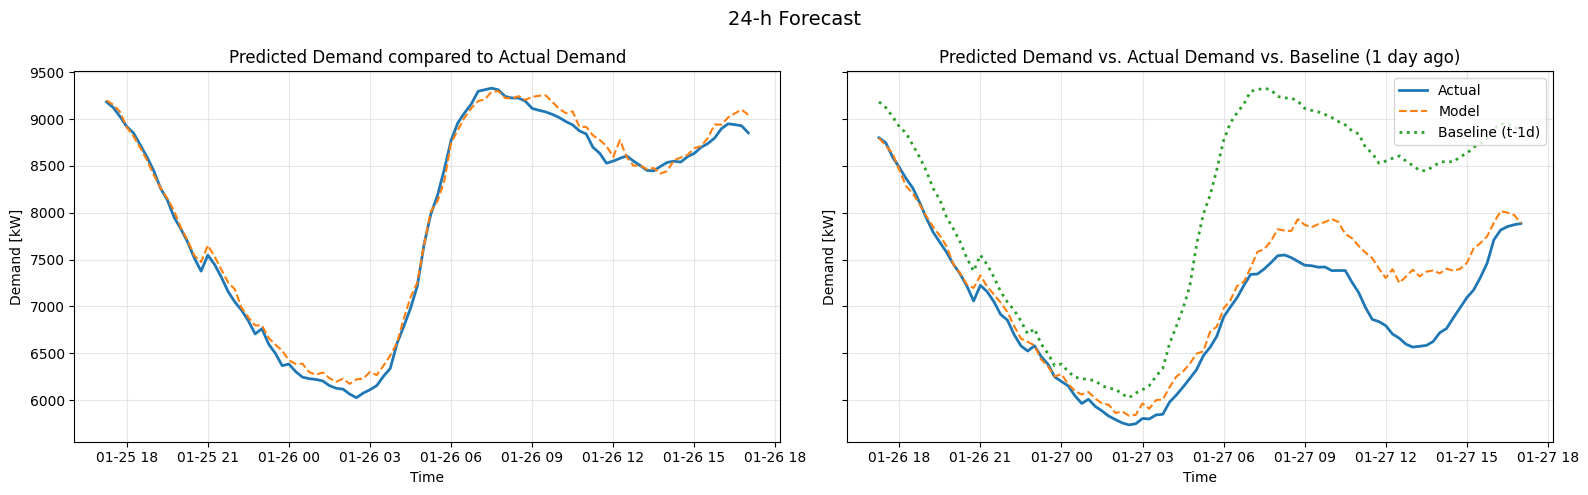

In [52]:
# plotting predicted demand compared to actual demand
HORIZON = y_te.shape[1]
SHIFT   = 96
idx_earlier = 0
idx_later   = SHIFT

y_pred_base = y_te.shift(SHIFT, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, idx, label in zip(
        axes,
        [idx_earlier, idx_later],
        ["Predicted Demand compared to Actual Demand", "Predicted Demand vs. Actual Demand vs. Baseline (1 day ago)"]):

    actual_day   = y_te.iloc[idx]
    pred_day     = y_pred.iloc[idx]
    baseline_day = y_pred_base.iloc[idx]

    time_axis = pd.date_range(
        start=df.loc[X_te.index[idx], "DateTime"] + pd.Timedelta(minutes=15),
        periods=HORIZON, freq="15min"
    )

    ax.plot(time_axis, actual_day.values,   label="Actual",           linewidth=2)
    ax.plot(time_axis, pred_day.values,     label="Model",            linestyle="--")
    ax.plot(time_axis, baseline_day.values, label="Baseline (t-1d)",  linestyle=":", linewidth=2)
    ax.set_xlabel("Time")
    ax.set_ylabel("Demand [kW]")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

axes[1].legend(loc="upper right")
fig.suptitle("24-h Forecast", fontsize=14)
fig.tight_layout()
plt.show()


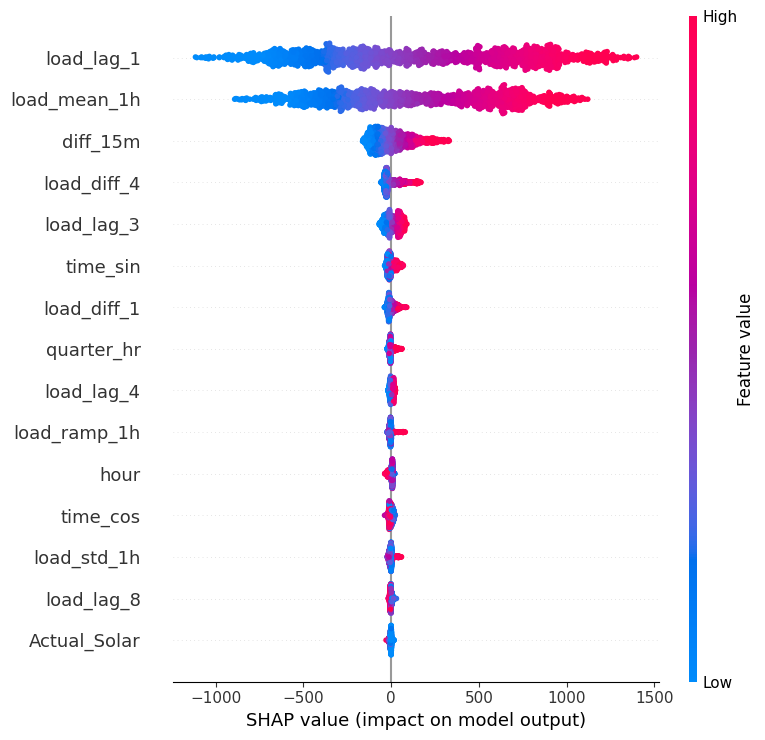

In [30]:
# feature importance
horizon_idx = 0
explainer   = shap.TreeExplainer(model.estimators_[horizon_idx])
X_sample   = X_te.iloc[:2000]
shap_vals  = explainer.shap_values(X_sample)


shap.summary_plot(
    shap_vals,
    X_sample,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.show()

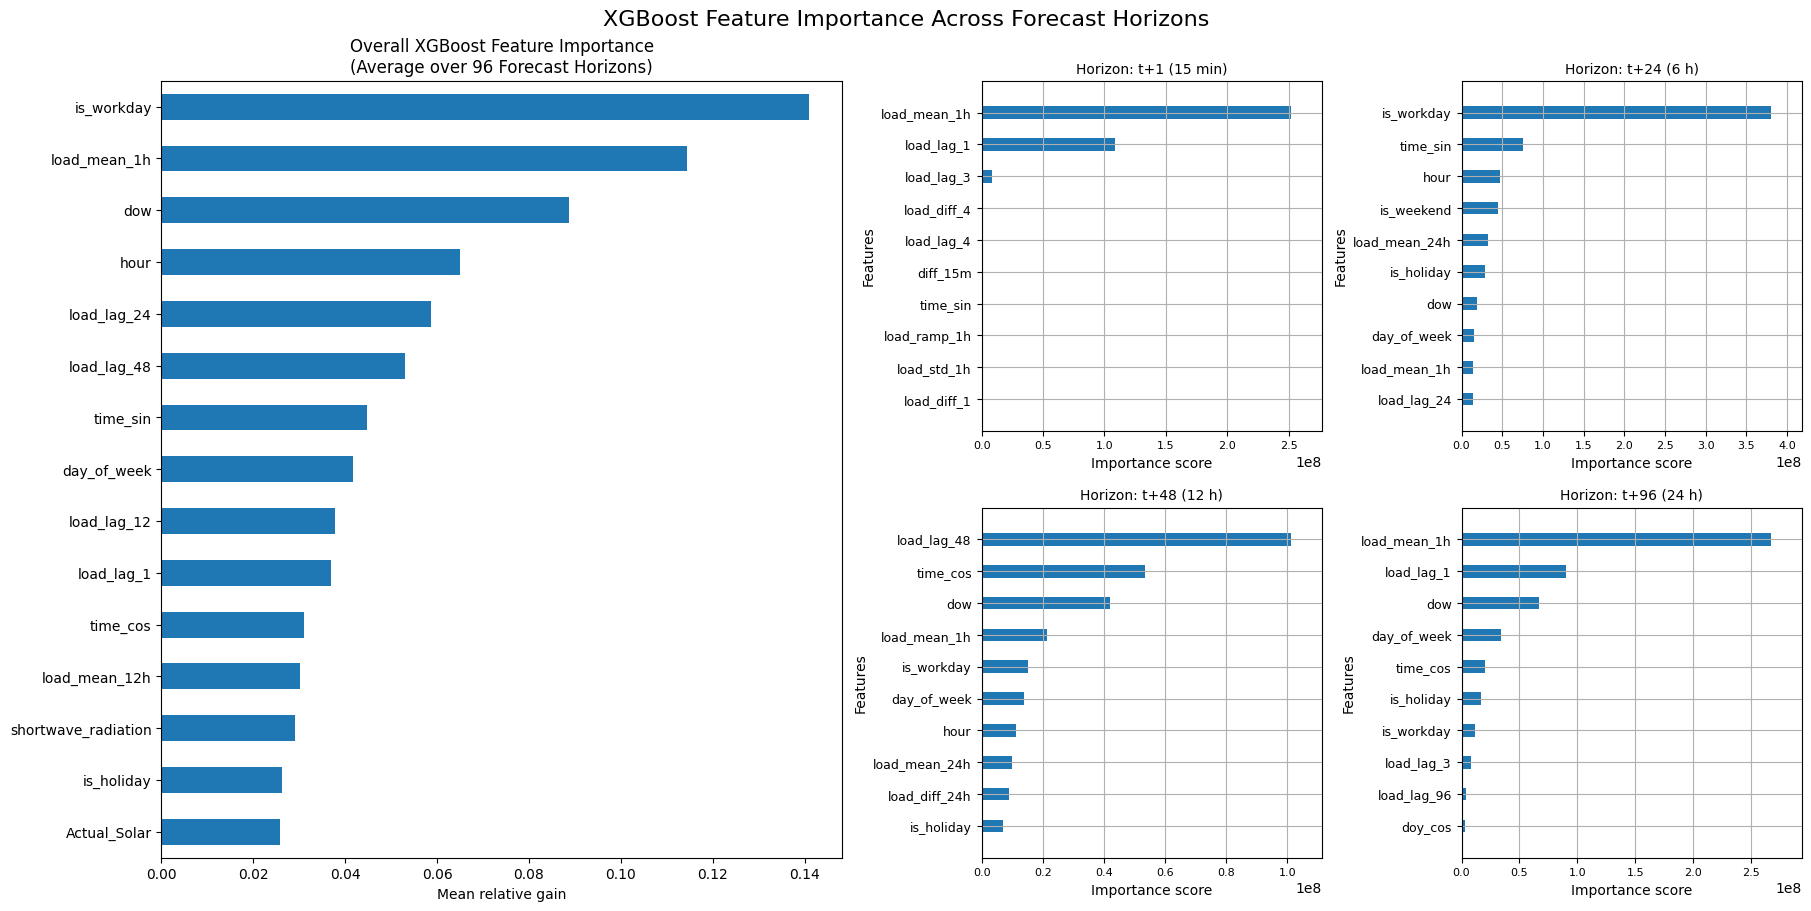

In [54]:
# feature importance
horizons = {
    "t+1 (15 min)" : 0,
    "t+24 (6 h)"   : 23,
    "t+48 (12 h)"  : 47,
    "t+96 (24 h)"  : 95,
}

gain_list = []
for est in model.estimators_:
    booster = est.get_booster()
    gdict   = booster.get_score(importance_type="gain")
    total   = sum(gdict.values()) or 1.0
    gain_list.append({k: v / total for k, v in gdict.items()})

gain_df = pd.DataFrame(gain_list).fillna(0.0)
top_k   = gain_df.mean(axis=0).sort_values(ascending=False).head(15)

# -------- Layout-optimierte Darstellung --------
fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs  = gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[2.0, 1, 1])

# (a) Linker Balkenplot (gesamt)
ax_big = fig.add_subplot(gs[:, 0])
top_k[::-1].plot.barh(ax=ax_big)
ax_big.set_xlabel("Mean relative gain")
ax_big.set_title("Overall XGBoost Feature Importance\n(Average over 96 Forecast Horizons)")

# (b) Einzelhorizonte rechts
axes_small = [fig.add_subplot(gs[r, c]) for r in range(2) for c in (1, 2)]

for ax, (label, idx) in zip(axes_small, horizons.items()):
    xgb.plot_importance(
        model.estimators_[idx],
        ax=ax,
        max_num_features=10,
        height=0.4,
        importance_type="gain",
        show_values=False
    )
    ax.set_title(f"Horizon: {label}", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=9)

# Haupttitel
fig.suptitle("XGBoost Feature Importance Across Forecast Horizons", fontsize=16)
plt.show()


In [33]:
import shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt

HORIZON = y_te.shape[1]          # 96
all_shap = [
    shap.TreeExplainer(model.estimators_[h]).shap_values(X_te)
    for h in range(HORIZON)
]

# stack → (HORIZON * n_samples, n_features), take absolute
shap_mat = np.abs(np.vstack(all_shap))
shap_df  = pd.DataFrame(shap_mat, columns=X_te.columns)

mean_abs_shap = shap_df.mean().sort_values(ascending=False)
top_k         = mean_abs_shap.head(15)

plt.figure(figsize=(8, 5))
top_k[::-1].plot.barh()
plt.xlabel("Mean |SHAP value|")
plt.title("Overall SHAP Importance (96 horizons averaged)")
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

C:\Users\Julia\AppData\Local\Temp\ipykernel_2120\2691502431.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=season_order, showfliers=False)


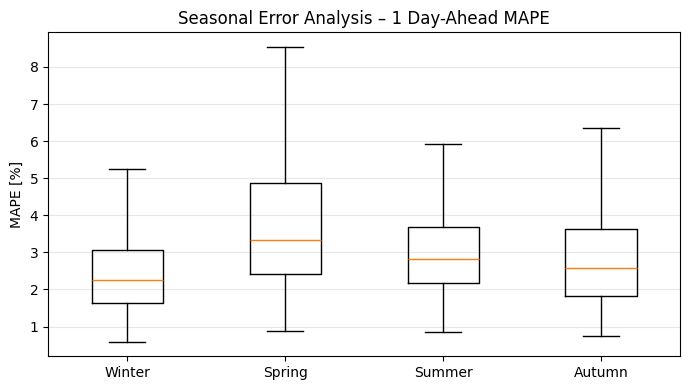

In [66]:
# Seasonal error analysis – 1 day-ahead MAPE per season

def get_season(ts):
    m = ts.month
    return ("Winter" if m in [12, 1, 2] else
            "Spring" if m in [3, 4, 5] else
            "Summer" if m in [6, 7, 8] else
            "Autumn")

season = df.loc[y_te.index, "DateTime"].apply(get_season)

mape_daily = (np.abs((y_te - y_pred) / y_te).mean(axis=1) * 100)   # Series

season_order = ["Winter", "Spring", "Summer", "Autumn"]
data = [mape_daily[season == s] for s in season_order]

plt.figure(figsize=(7, 4))
plt.boxplot(data, labels=season_order, showfliers=False)
plt.ylabel("MAPE [%]")
plt.title("Seasonal Error Analysis – 1 Day-Ahead MAPE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()




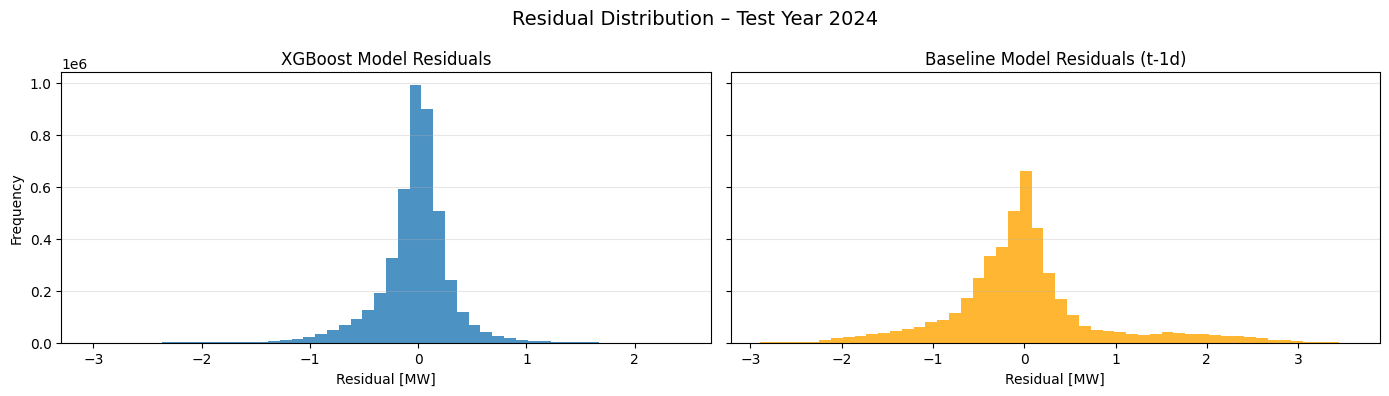

In [60]:
# Residual distribution – xgboost model vs. baseline model (1d ago)
SHIFT = 96                                    # 24 h = 96 × 15-min steps

# baseline forecast = actual load from 24 h earlier
y_pred_base = y_te.shift(SHIFT, axis=0)

# residuals [MW]
res_model = ((y_te - y_pred)      / 1000).values.flatten()
res_base  = ((y_te - y_pred_base) / 1000).values.flatten()
res_base  = res_base[~np.isnan(res_base)]       # drop NaNs from first 24 h

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(res_model, bins=50, alpha=0.8)
axes[0].set_title("XGBoost Model Residuals")
axes[0].set_xlabel("Residual [MW]")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(res_base, bins=50, alpha=0.8, color="orange")
axes[1].set_title("Baseline Model Residuals (t-1d)")
axes[1].set_xlabel("Residual [MW]")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Residual Distribution – Test Year 2024", fontsize=14)
fig.tight_layout()
plt.show()